<a href="https://colab.research.google.com/github/NathanBvumbwe/student_perfomance_system/blob/main/kmeans_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

importing the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

loading the data

In [2]:
scaled_df = pd.read_csv("scaled_data.csv")
clean_df = pd.read_csv("cleaned_data.csv")

Inspect Data

In [3]:
scaled_df.head()

,age,gender,study_hours_per_day,attendance_percentage,sleep_hours,internet_usage_hours,exam_score
0,1.500363,-1.000122,-1.236074,0.077241,-0.484330,0.069720,-1.151355
1,-0.000147,0.999878,-0.740969,1.228890,-1.038006,-1.384841,-0.334524
2,0.500023,-1.000122,-1.582648,-0.329733,0.000136,-0.830722,-2.002945
3,1.500363,0.999878,0.892880,0.362988,1.176697,1.455017,1.554037
4,-0.500317,0.999878,0.397774,1.332799,-1.730101,-1.315576,0.349066


In [4]:
scaled_df.shape

(1000000, 7)

In [5]:
scaled_df.describe()

,age,gender,study_hours_per_day,attendance_percentage,sleep_hours,internet_usage_hours,exam_score
count,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06
mean,-1.560228e-16,2.473755e-17,-2.428351e-16,5.772449e-17,4.104095e-16,-7.079848e-17,1.091252e-16
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000000e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-1.500657e+00,-1.000122e+00,-1.731180e+00,-1.732495e+00,-1.730101e+00,-1.731165e+00,-3.016743e+00
25%,-1.000487e+00,-1.000122e+00,-8.399897e-01,-8.665927e-01,-8.995870e-01,-8.999870e-01,-8.095604e-01
50%,-1.470500e-04,9.998780e-01,1.689845e-03,-6.906435e-04,1.362735e-04,4.556240e-04,1.477781e-03
75%,1.000193e+00,9.998780e-01,8.433694e-01,8.652114e-01,8.998595e-01,8.316334e-01,8.125160e-01
max,1.500363e+00,9.998780e-01,1.734560e+00,1.731114e+00,1.730373e+00,1.732076e+00,2.318730e+00


Elbow Method (Find Best K)

In [6]:
inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

Plot Elbow Curve

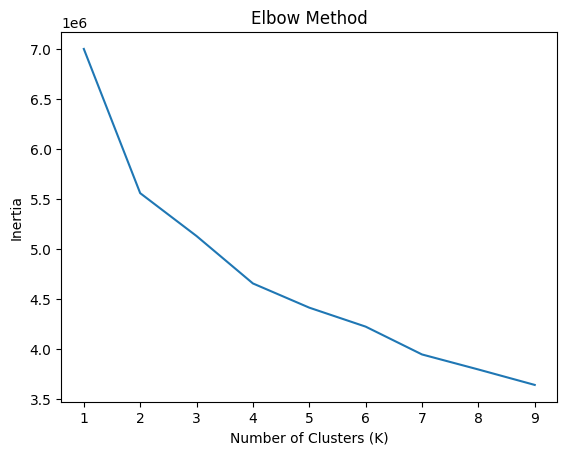

In [7]:
plt.figure()
plt.plot(K_range, inertia)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

train final model

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_df)

attach clusters to clean data

In [9]:
clean_df['cluster'] = clusters
clean_df.head()

,age,gender,study_hours_per_day,attendance_percentage,sleep_hours,internet_usage_hours,exam_score,cluster
0,24,0,2.0,80.9,5.8,3.6,40.1,1
1,21,1,3.0,94.2,5.0,1.5,54.2,0
2,22,0,1.3,76.2,6.5,2.3,25.4,1
3,24,1,6.3,84.2,8.2,5.6,86.8,2
4,20,1,5.3,95.4,4.0,1.6,66.0,0


Analyze Clusters

In [10]:
cluster_summary = clean_df.groupby('cluster').mean()
cluster_summary

,age,gender,study_hours_per_day,attendance_percentage,sleep_hours,internet_usage_hours,exam_score
cluster,,,,,,,
0,20.988023,0.496001,3.011538,90.377287,6.500435,3.492473,50.962978
1,21.010868,0.503532,3.027638,69.624837,6.498655,3.495152,44.621307
2,21.000856,0.500266,6.463954,80.533716,6.500192,3.506642,76.362567


In [17]:
def map_cluster(label):
    if label == 0:
        return "At Risk"
    elif label == 1:
        return "Average"
    elif label == 2:
        return "Top Performer"

clean_df['performance_group'] = clean_df['cluster'].map(map_cluster)

In [18]:
clean_df[['cluster', 'performance_group']].head()

,cluster,performance_group
0,1,Average
1,0,At Risk
2,1,Average
3,2,Top Performer
4,0,At Risk


🔟 Count Students per Cluster

In [11]:
clean_df['cluster'].value_counts()

,count
cluster,
2,428766
1,296289
0,274945


1️⃣1️⃣ Visualize Clusters (2D Projection)

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_df)

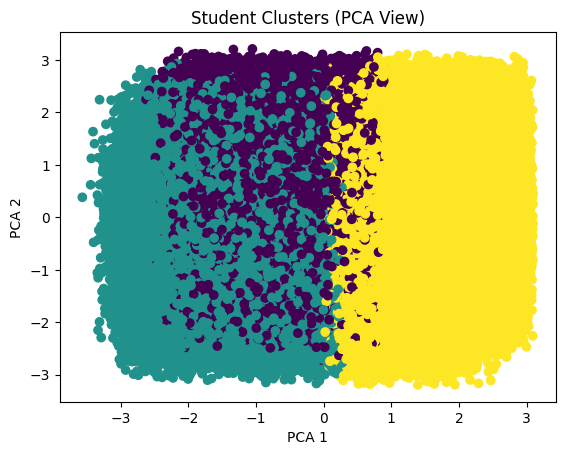

In [13]:
plt.figure()
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters)
plt.title("Student Clusters (PCA View)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

1️⃣2️⃣ Save Model (IMPORTANT FOR DJANGO)

In [14]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [16]:
from google.colab import files
files.download("kmeans_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CHECKING THE WORTHY AND SERIOUSNESS OF THE MODEL😂😂😂😂😂😂.... IS IT DOING THE JOB INIT

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_df, clusters)
print("Silhouette Score:", score)

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    print(f"K={k}, Silhouette Score={score}")